In [3]:
train_data = pd.read_csv(
    'train_data.txt',
    sep=':::',
    engine='python',
    header=None,
    names=['ID','Title','Genre','Description']
)

print(train_data.head())

   ID                               Title       Genre  \
0   1       Oscar et la dame rose (2009)       drama    
1   2                       Cupid (1997)    thriller    
2   3   Young, Wild and Wonderful (1980)       adult    
3   4              The Secret Sin (1915)       drama    
4   5             The Unrecovered (2007)       drama    

                                         Description  
0   Listening in to a conversation between his do...  
1   A brother and sister with a past incestuous r...  
2   As the bus empties the students for their fie...  
3   To help their unemployed father make ends mee...  
4   The film's title refers not only to the un-re...  


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Input features
X = train_data['Description']

# Target variable
y = train_data['Genre']

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X = tfidf.fit_transform(X)

print("Feature matrix shape:", X.shape)
print("Total genres:", y.nunique())

Feature matrix shape: (54214, 5000)
Total genres: 27


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Validation data size:", X_val.shape)

Training data size: (43371, 5000)
Validation data size: (10843, 5000)


In [6]:
from sklearn.naive_bayes import MultinomialNB

# Initialize model
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully")

Model training completed successfully


In [7]:
from sklearn.metrics import accuracy_score

# Predict genres for validation data
y_pred = model.predict(X_val)

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5225491100249009


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

               precision    recall  f1-score   support

      action        0.58      0.08      0.15       263
       adult        0.88      0.06      0.12       112
   adventure        0.29      0.03      0.05       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.51      0.44      0.47      1443
       crime        0.00      0.00      0.00       107
 documentary        0.57      0.88      0.70      2659
       drama        0.46      0.83      0.59      2697
      family        1.00      0.01      0.01       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.15      0.26        40
     history        0.00      0.00      0.00        45
      horror        0.73      0.38      0.50       431
       music        0.79      0.10      0.18       144
     musical        0.00      0.00      0.00        50
     mystery        0.00      0.00      0.00        56
        n

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)
print(cm)

[[  22    0    0    0    0   19    0   51  155    0    0    0    0    7
     0    0    0    0    0    0    0    3    3    0    2    0    1]
 [   0    7    7    0    0   35    0    8   51    0    0    0    0    1
     0    0    0    0    0    0    0    3    0    0    0    0    0]
 [   3    1    4    0    0   15    0   35   71    0    0    0    0    6
     0    0    0    0    0    0    0    2    0    0    1    0    1]
 [   0    0    0    0    0   23    0   37   40    0    0    0    0    1
     0    0    0    0    0    0    0    3    0    0    0    0    0]
 [   0    0    0    0    0    2    0   42   17    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]
 [   3    0    1    0    0  629    0  152  643    0    0    0    0    6
     1    0    0    0    0    0    0    8    0    0    0    0    0]
 [   1    0    0    0    0    8    0    8   85    0    0    0    0    2
     0    0    0    0    0    0    0    1    0    0    1    0    1]
 [   1    0    0    

In [10]:
test_data = pd.read_csv(
    'test_data.txt',
    sep=':::',
    engine='python',
    header=None,
    names=['ID','Title','Description']
)

print(test_data.head())

   ID                          Title  \
0   1          Edgar's Lunch (1998)    
1   2      La guerra de papá (1977)    
2   3   Off the Beaten Track (2010)    
3   4        Meu Amigo Hindu (2015)    
4   5             Er nu zhai (1955)    

                                         Description  
0   L.R. Brane loves his life - his car, his apar...  
1   Spain, March 1964: Quico is a very naughty ch...  
2   One year in the life of Albin and his family ...  
3   His father has died, he hasn't spoken with hi...  
4   Before he was known internationally as a mart...  


In [11]:
X_test = tfidf.transform(test_data['Description'])

print("Test feature matrix shape:", X_test.shape)

Test feature matrix shape: (54200, 5000)


In [12]:
test_predictions = model.predict(X_test)

print(test_predictions[:10])

[' drama ' ' drama ' ' documentary ' ' drama ' ' drama ' ' drama '
 ' drama ' ' drama ' ' documentary ' ' drama ']


In [13]:
test_data['Predicted_Genre'] = test_predictions

print(test_data.head())

   ID                          Title  \
0   1          Edgar's Lunch (1998)    
1   2      La guerra de papá (1977)    
2   3   Off the Beaten Track (2010)    
3   4        Meu Amigo Hindu (2015)    
4   5             Er nu zhai (1955)    

                                         Description Predicted_Genre  
0   L.R. Brane loves his life - his car, his apar...          drama   
1   Spain, March 1964: Quico is a very naughty ch...          drama   
2   One year in the life of Albin and his family ...    documentary   
3   His father has died, he hasn't spoken with hi...          drama   
4   Before he was known internationally as a mart...          drama   


In [14]:
print(test_data['Predicted_Genre'].value_counts())

Predicted_Genre
drama           24683
documentary     20142
comedy           6118
horror           1041
short             949
western           628
action            195
music              96
adventure          82
thriller           65
game-show          57
sport              47
adult              44
sci-fi             33
reality-tv         20
Name: count, dtype: int64


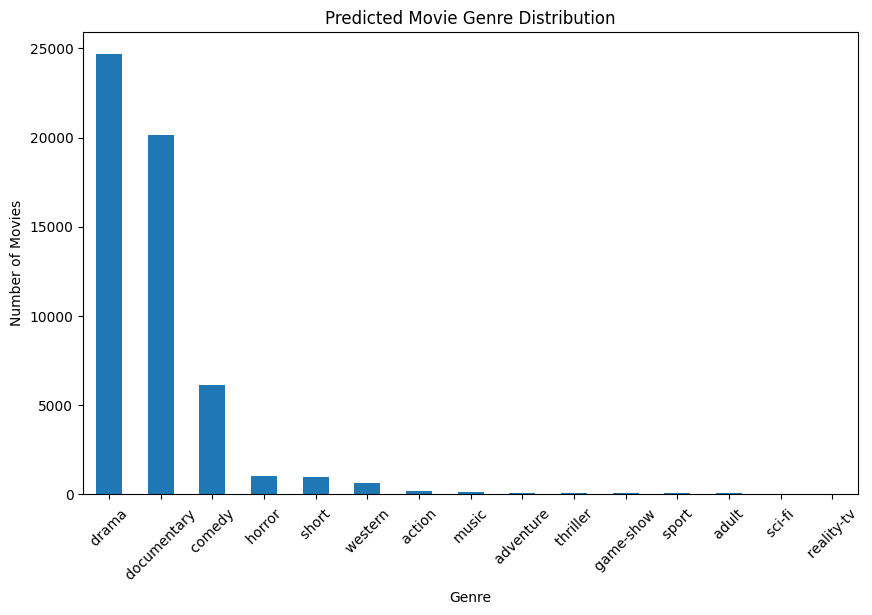

In [15]:
import matplotlib.pyplot as plt

test_data['Predicted_Genre'].value_counts().plot(kind='bar', figsize=(10,6))
plt.title("Predicted Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [16]:
print(test_data[['Description','Predicted_Genre']].head(10))

                                         Description Predicted_Genre
0   L.R. Brane loves his life - his car, his apar...          drama 
1   Spain, March 1964: Quico is a very naughty ch...          drama 
2   One year in the life of Albin and his family ...    documentary 
3   His father has died, he hasn't spoken with hi...          drama 
4   Before he was known internationally as a mart...          drama 
5   Emily Burns is being held captive in a room w...          drama 
6   The beautiful but neglected wife of a brillia...          drama 
7   Vasu Inamdar (Ina) suffers from a disorder wh...          drama 
8   An insight into the tornados that hit Kensal ...    documentary 
9   Press is a story of young people overwhelmed ...          drama 


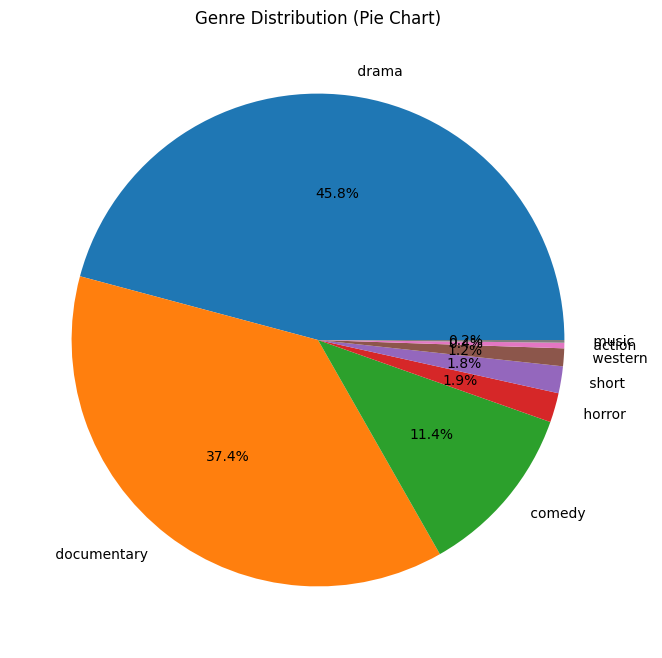

In [17]:
genre_counts = test_data['Predicted_Genre'].value_counts().head(8)

plt.figure(figsize=(8,8))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%')
plt.title("Genre Distribution (Pie Chart)")
plt.show()

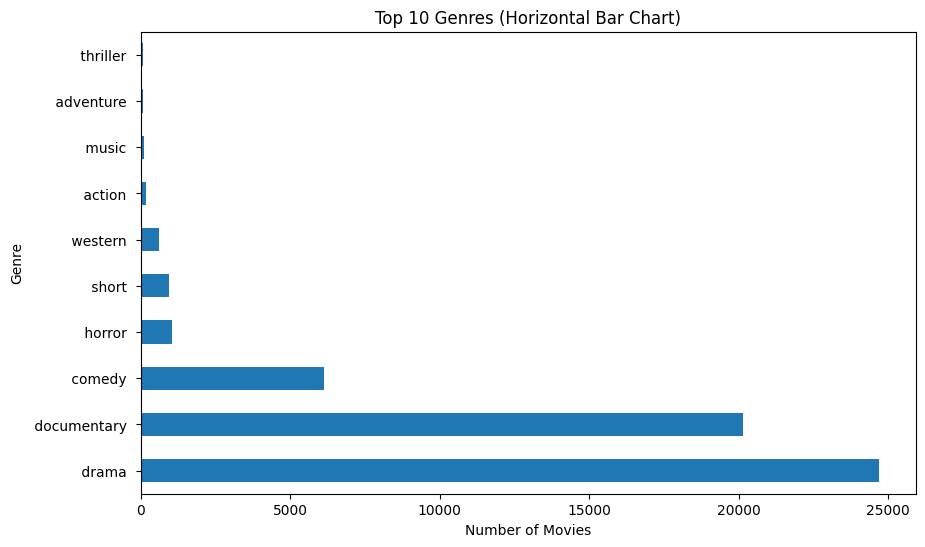

In [18]:
plt.figure(figsize=(10,6))
test_data['Predicted_Genre'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Genres (Horizontal Bar Chart)")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

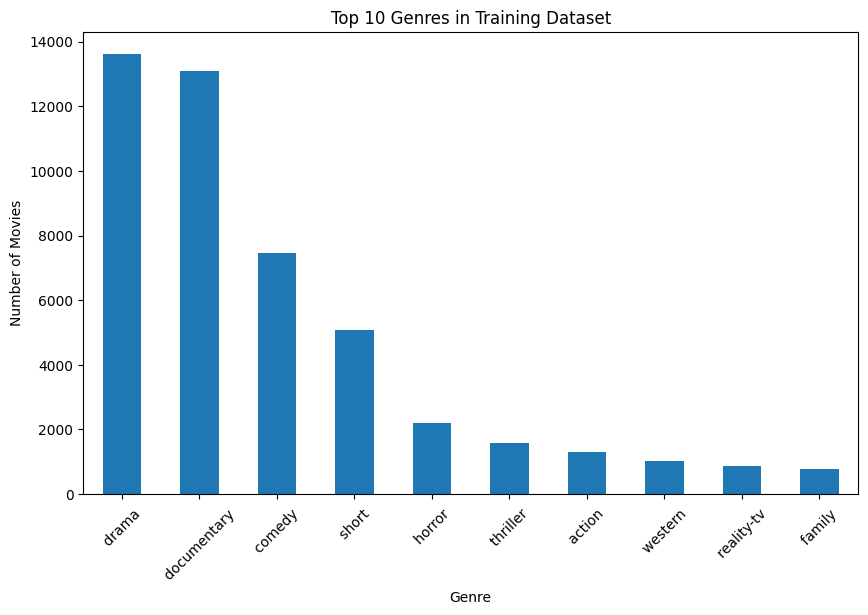

In [19]:
plt.figure(figsize=(10,6))
train_data['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres in Training Dataset")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [20]:
test_data.to_csv("movie_genre_predictions.csv", index=False)

print("Prediction file saved successfully")

Prediction file saved successfully


In [21]:
print("===================================")
print(" Movie Genre Prediction Completed ")
print(" Model: Multinomial Naive Bayes")
print(" Predictions saved to movie_genre_predictions.csv")
print("===================================")

 Movie Genre Prediction Completed 
 Model: Multinomial Naive Bayes
 Predictions saved to movie_genre_predictions.csv
